### REGRESI: Peramalan (Forecasting) Beban Puncak Konsumsi Energi Listrik Berdasarkan Pola Cuaca Historis

**Tujuan Proyek:**
Membangun model Machine Learning berbasis *Time Series* untuk memprediksi beban puncak konsumsi energi listrik (MW) secara *real-time* (horizon 6 jam) menggunakan data historis beban dan pola cuaca. 

**Aturan Ketat (Strict Rules):**
1. Mencegah *Data Leakage* dengan menghapus data masa depan (forecast) dan harga aktual.
2. Pemotongan data (*Splitting*) dilakukan secara kronologis (*Time-Based*), bukan acak.
3. Preprocessing (Scaling) hanya di-*fit* pada data *Training*.

In [1]:
# ==========================================
# IMPORT LIBRARIES & SETUP ENVIRONMENT
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ast

# Sklearn: Model Selection & Preprocessing
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Sklearn: Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Sklearn: Algorithms
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Konfigurasi Visualisasi & Warning
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Modul dan Library berhasil dimuat.")

Modul dan Library berhasil dimuat.


### 1. Data Understanding
Pada tahap ini, kita akan memuat dua dataset utama:
1. **Energy Dataset (`energy_dataset_train.csv`):** Berisi rekaman aktual dari total beban listrik (`total load actual`) per jam. Data ini bertindak sebagai variabel target (Y) dan dasar pembuatan fitur historis (*lag*).
2. **Weather Dataset (`weather_features.csv`):** Berisi data cuaca historis seperti suhu (`temp`), kelembapan (`humidity`), dan kondisi cuaca lainnya. Data ini bertindak sebagai variabel prediktor (X).

In [2]:
# ==========================================
#  LOAD DATA
# ==========================================
# Memuat data energi dan cuaca
df_energy = pd.read_csv('energy_dataset_train.csv')
df_weather = pd.read_csv('weather_features.csv')

# Menyamakan format waktu menjadi Datetime dan menghapus zona waktu (UTC)
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True).dt.tz_localize(None)
df_weather['time'] = pd.to_datetime(df_weather['time'], utc=True).dt.tz_localize(None)

print(f"Data Energi dimuat dengan {df_energy.shape[0]} baris dan {df_energy.shape[1]} kolom.")
print(f"Data Cuaca dimuat dengan {df_weather.shape[0]} baris dan {df_weather.shape[1]} kolom.")

Data Energi dimuat dengan 32064 baris dan 29 kolom.
Data Cuaca dimuat dengan 32060 baris dan 9 kolom.


**Integrasi Data dan Pencegahan Data Leakage**

Sebelum melihat statistik deskriptif, kita wajib membersihkan dataset dari *Data Leakage* (Kebocoran Data).
Kolom seperti `total load forecast`, `price actual`, dan data pembangkitan (*generation*) spesifik di masa depan harus dihapus karena di dunia nyata, data ini belum ada saat kita mencoba memprediksi beban listrik untuk besok.

In [3]:
# ==========================================
# PENCEGAHAN DATA LEAKAGE & MERGING
# ==========================================
# Mendefinisikan kolom yang berpotensi menyebabkan Data Leakage atau tidak relevan
leakage_and_useless_cols = [
    'total load forecast', 'price actual', 'price day ahead',
    'forecast wind offshore eday ahead', 'generation hydro pumped storage aggregated',
    'generation fossil coal-derived gas', 'generation fossil oil shale', 
    'generation fossil peat', 'generation geothermal', 'generation marine', 
    'generation wind offshore', 'generation biomass', 'generation fossil brown coal/lignite', 
    'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil',
    'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage',
    'generation hydro water reservoir', 'generation nuclear', 'generation other renewable', 
    'generation solar', 'generation waste', 'generation wind onshore', 'generation other',
    'forecast solar day ahead', 'forecast wind onshore day ahead'
]

# Menghapus kolom berbahaya dari data energi
df_energy = df_energy.drop(columns=[col for col in leakage_and_useless_cols if col in df_energy.columns])

# Menggabungkan data (Inner Join) berdasarkan kolom waktu yang sudah disamakan
df = pd.merge(df_energy, df_weather, on='time', how='inner')

print("Data berhasil digabungkan (Merge) dan bebas dari Data Leakage.")

Data berhasil digabungkan (Merge) dan bebas dari Data Leakage.


**Statistik Deskriptif dan Info Dataset**

Setelah digabungkan, kita memeriksa struktur data, tipe data, dan statistik dasar untuk mendeteksi apakah masih ada *missing values* atau nilai anomali (*outliers*) yang ekstrim.

In [4]:
# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================
print("=== INFORMASI DATASET FINAL ===")
df.info()

=== INFORMASI DATASET FINAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32059 entries, 0 to 32058
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               32059 non-null  datetime64[ns]
 1   total load actual  32023 non-null  float64       
 2   temp               32059 non-null  float64       
 3   pressure           32059 non-null  float64       
 4   humidity           32059 non-null  float64       
 5   wind_speed         32059 non-null  float64       
 6   wind_deg           32059 non-null  float64       
 7   rain_1h            32059 non-null  float64       
 8   clouds_all         32059 non-null  float64       
 9   weather_main       32059 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 2.4+ MB


In [5]:
print("\n=== STATISTIK DESKRIPTIF ===")
df.describe()


=== STATISTIK DESKRIPTIF ===


,time,total load actual,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,clouds_all
count,32059,32023.000000,32059.000000,32059.000000,32059.000000,32059.000000,32059.000000,32059.000000,32059.000000
mean,2016-10-29 23:06:15.956829696,28672.943384,289.773133,1016.026574,67.680721,2.482744,166.875770,0.075111,24.591571
min,2015-01-01 00:00:00,18041.000000,271.941863,974.600000,26.400000,0.000000,0.000000,0.000000,0.000000
25%,2015-11-30 23:30:00,24797.500000,284.098000,1012.600000,56.200000,1.400000,126.633333,0.000000,12.000000
50%,2016-10-29 23:00:00,28881.000000,289.143500,1016.800000,69.200000,2.200000,166.600000,0.000000,22.000000
75%,2017-09-28 22:30:00,32130.000000,295.212000,1020.600000,79.600000,3.200000,208.000000,0.060000,35.000000
max,2018-08-28 22:00:00,41015.000000,309.266000,1039.800000,100.000000,29.800000,338.000000,4.150000,92.000000
std,NaN,4566.985723,7.324097,8.360939,14.854420,1.385651,57.621337,0.207918,17.306302


In [6]:
print("\n=== SAMPEL DATA TERATAS ===")
df.head()


=== SAMPEL DATA TERATAS ===


,time,total load actual,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,clouds_all,weather_main
0,2015-01-01 00:00:00,24382.0,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,clear
1,2015-01-01 01:00:00,22734.0,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,clear
2,2015-01-01 02:00:00,21286.0,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,clear
3,2015-01-01 03:00:00,20264.0,272.089469,1016.6,82.0,2.4,119.2,0.0,0.0,clear
4,2015-01-01 04:00:00,19905.0,272.145900,1016.6,82.0,2.4,118.4,0.0,0.0,clear


### 2. Data Preprocessing & Feature Engineering
Tahapan ini sangat krusial untuk peramalan (*forecasting*) deret waktu. Langkah-langkah yang dilakukan:
1. **Penanganan Missing Values:** Menggunakan teknik interpolasi berbasis waktu agar garis tren tetap natural.
2. **Ekstraksi Waktu & Cyclical Encoding:** Mengekstrak hari dan jam, serta mengubah jam menjadi fungsi Sinus/Cosinus agar model memahami bahwa waktu bersifat siklus (berulang).
3. **Pembuatan Lag Features (Horizon 6 Jam):** Sesuai skenario *real-time operasional*, kita hanya menggunakan data historis minimal 6 jam ke belakang (`t-6`). Kita menghindari `t-1` agar model tidak bersifat *trivial* (hanya mencontek jam sebelumnya).
4. **Encoding Kategorikal:** Mengubah deskripsi cuaca menjadi data numerik (*One-Hot Encoding*).

In [7]:
# ==========================================
# 2. DATA PREPROCESSING (PIPELINE FUNCTION)
# ==========================================

def preprocess_time_series(df_raw):
    """
    Fungsi untuk memproses data mentah menjadi data siap latih/prediksi.
    Menerapkan Horizon 6-Jam untuk simulasi Real-Time Forecasting.
    """
    # 0. Copy data agar tidak mengubah dataset asli di memori
    df = df_raw.copy()
    
    # 1. Set index waktu dan urutkan
    df = df.set_index('time').sort_index()

    # 2. Penanganan Missing Values
    df = df.interpolate(method='time').fillna(method='ffill').fillna(method='bfill')

    # 3. Ekstraksi Waktu Dasar
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    # 4. Cyclical Encoding (Siklus Jam)
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

    # 5. Lag Features (Horizon 6 Jam)
    df['load_lag_6h'] = df['total load actual'].shift(6)
    df['load_lag_12h'] = df['total load actual'].shift(12)
    df['load_lag_24h'] = df['total load actual'].shift(24)
    df['load_lag_168h'] = df['total load actual'].shift(168)

    # 6. Fitur Non-Linear & Rolling
    df['load_rolling_mean_6h'] = df['total load actual'].shift(6).rolling(window=6).mean()
    df['temp_lag_6h'] = df['temp'].shift(6)
    df['temp_squared'] = df['temp'] ** 2 

    # 7. Encoding Kategorikal
    df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

    # 8. Hapus baris NaN akibat shift
    df = df.dropna()

    # Pastikan numerik
    df = df.astype(float)
    
    return df

# Eksekusi fungsi pada data gabungan kita
df_clean = preprocess_time_series(df)

print("Pipeline Preprocessing berhasil dijalankan.")
print(f"Dimensi data akhir: {df_clean.shape}")

# PENTING: Update variabel X dan y menggunakan data yang sudah bersih
# (Ini menggantikan deklarasi X dan y di awal Cell 5)
X = df_clean.drop(columns=['total load actual'])
y = df_clean['total load actual']

Pipeline Preprocessing berhasil dijalankan.
Dimensi data akhir: (31891, 28)


In [8]:
# ==========================================
# CELL 3: REFINED FEATURE ENGINEERING (6-HOUR HORIZON)
# ==========================================
# Set index waktu dan urutkan
df = df.set_index('time').sort_index()

# 0. PENANGANAN OUTLIER (Krusial untuk Cuaca)
# Mengganti nilai pressure yang tidak masuk akal dengan median
median_pres = df.loc[(df['pressure'] > 900) & (df['pressure'] < 1100), 'pressure'].median()
df.loc[(df['pressure'] > 1100) | (df['pressure'] < 900), 'pressure'] = median_pres

# 1. Interpolasi Missing Values (Berdasarkan waktu)
df = df.interpolate(method='time').fillna(method='ffill').fillna(method='bfill')

# 2. Ekstraksi Waktu Dasar
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# 3. CYCLICAL ENCODING (Wajib untuk Time Series)
# Mengubah jam menjadi pola lingkaran agar jam 23 dan 00 dianggap berdekatan
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

# 4. SAFE LAG FEATURES (Minimal Lag 6 Jam)
# Kita hapus lag_1h s.d lag_5h untuk mensimulasikan prediksi real-time 6 jam ke depan
df['load_lag_6h'] = df['total load actual'].shift(6)
df['load_lag_12h'] = df['total load actual'].shift(12)
df['load_lag_24h'] = df['total load actual'].shift(24) # Pola harian
df['load_lag_168h'] = df['total load actual'].shift(168) # Pola mingguan (t-7 hari)

# 5. SAFE ROLLING FEATURES (Jendela statistik 6 jam terakhir)
# Menghitung rata-rata beban dari jendela 6 jam yang lalu
df['load_rolling_mean_6h'] = df['total load actual'].shift(6).rolling(window=6).mean()

# 6. NON-LINEAR WEATHER FEATURES
# Pola beban puncak biasanya U-Shape terhadap suhu (sangat dingin/panas beban naik)
df['temp_lag_6h'] = df['temp'].shift(6)
df['temp_squared'] = df['temp'] ** 2 

# 7. ENCODING KATEGORIKAL (Weather Main)
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

# 8. Drop baris yang memiliki NaN akibat proses shifting (168 baris pertama)
df = df.dropna()

# Pastikan semua tipe data numerik
df = df.astype(float)

print("Feature Engineering (Safe Scenario) Selesai.")
print(f"Skenario: Real-time Forecasting (Horizon 6 Jam)")
print(f"Sisa baris data: {df.shape[0]}")

Feature Engineering (Safe Scenario) Selesai.
Skenario: Real-time Forecasting (Horizon 6 Jam)
Sisa baris data: 31891


### 3. Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan melakukan analisis visual untuk memahami karakteristik data sebelum dimasukkan ke dalam model:
1. **Distribusi Target:** Memastikan data target (Beban Listrik) tidak memiliki anomali/outlier ekstrem.
2. **Pola Runtut Waktu (Time Series):** Melihat pola harian dan mingguan dari konsumsi listrik.
3. **Analisis Korelasi:** Memverifikasi secara statistik bahwa fitur cuaca (`temp`) dan fitur buatan (`lag_24h`) memiliki hubungan linear yang relevan dengan fluktuasi beban listrik.

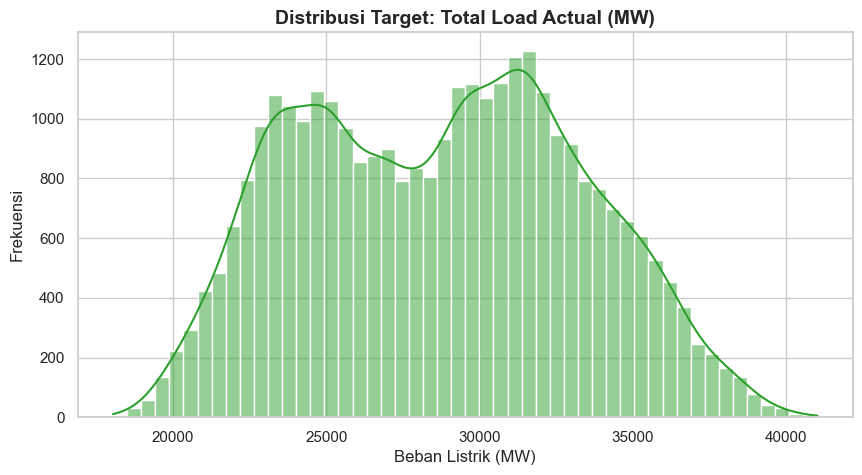

In [9]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# 1. Distribusi Target (Beban Listrik Aktual)
plt.figure(figsize=(10, 5))
sns.histplot(df['total load actual'], bins=50, kde=True, color='#2ca02c')
plt.title('Distribusi Target: Total Load Actual (MW)', fontsize=14, fontweight='bold')
plt.xlabel('Beban Listrik (MW)')
plt.ylabel('Frekuensi')
plt.show()

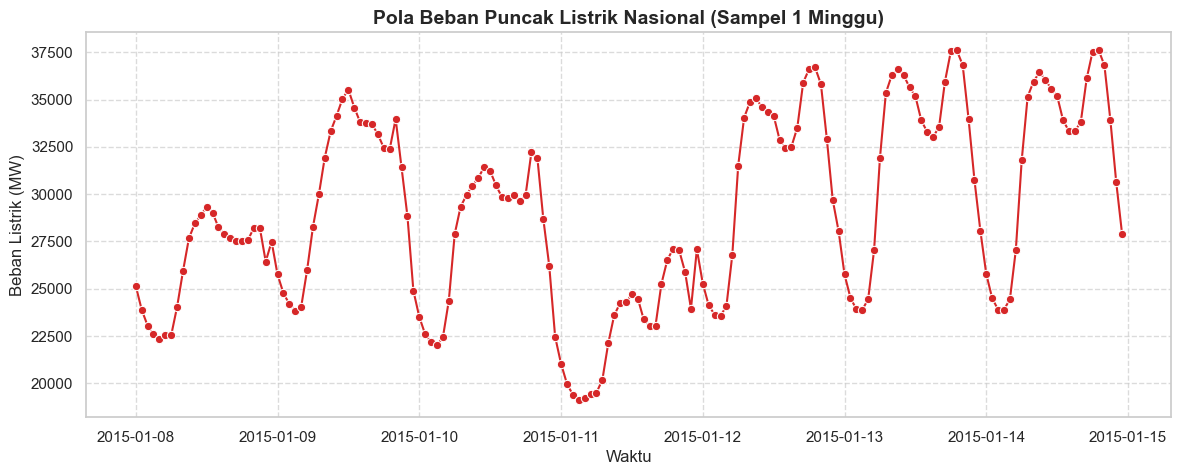

In [10]:

# 2. Visualisasi Pola Time Series (Mengambil sampel 1 Minggu Pertama)
plt.figure(figsize=(14, 5))
# Kita ambil 168 jam pertama (24 jam x 7 hari)
sns.lineplot(x=df.index[:168], y=df['total load actual'][:168], marker='o', color='#d62728')
plt.title('Pola Beban Puncak Listrik Nasional (Sampel 1 Minggu)', fontsize=14, fontweight='bold')
plt.xlabel('Waktu')
plt.ylabel('Beban Listrik (MW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

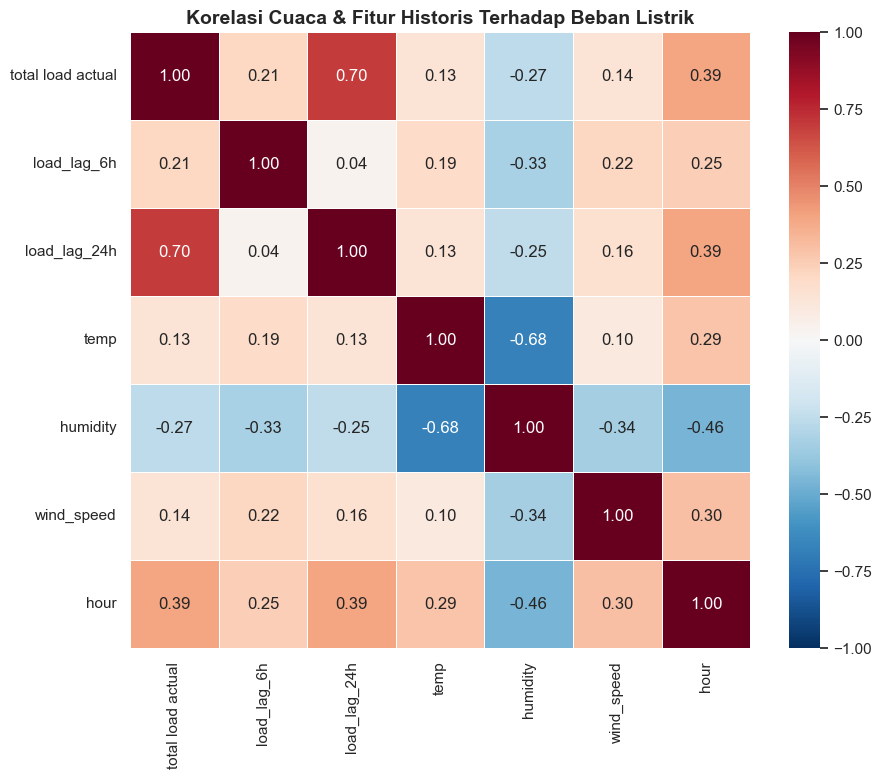

In [11]:
# 3. Heatmap Korelasi
# Kita pilih beberapa fitur paling penting agar visualisasi tidak terlalu penuh
cols_for_eda = [
    'total load actual', 'load_lag_6h', 'load_lag_24h', 
    'temp', 'humidity', 'wind_speed', 'hour'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_for_eda].corr(), annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korelasi Cuaca & Fitur Historis Terhadap Beban Listrik', fontsize=14, fontweight='bold')
plt.show()

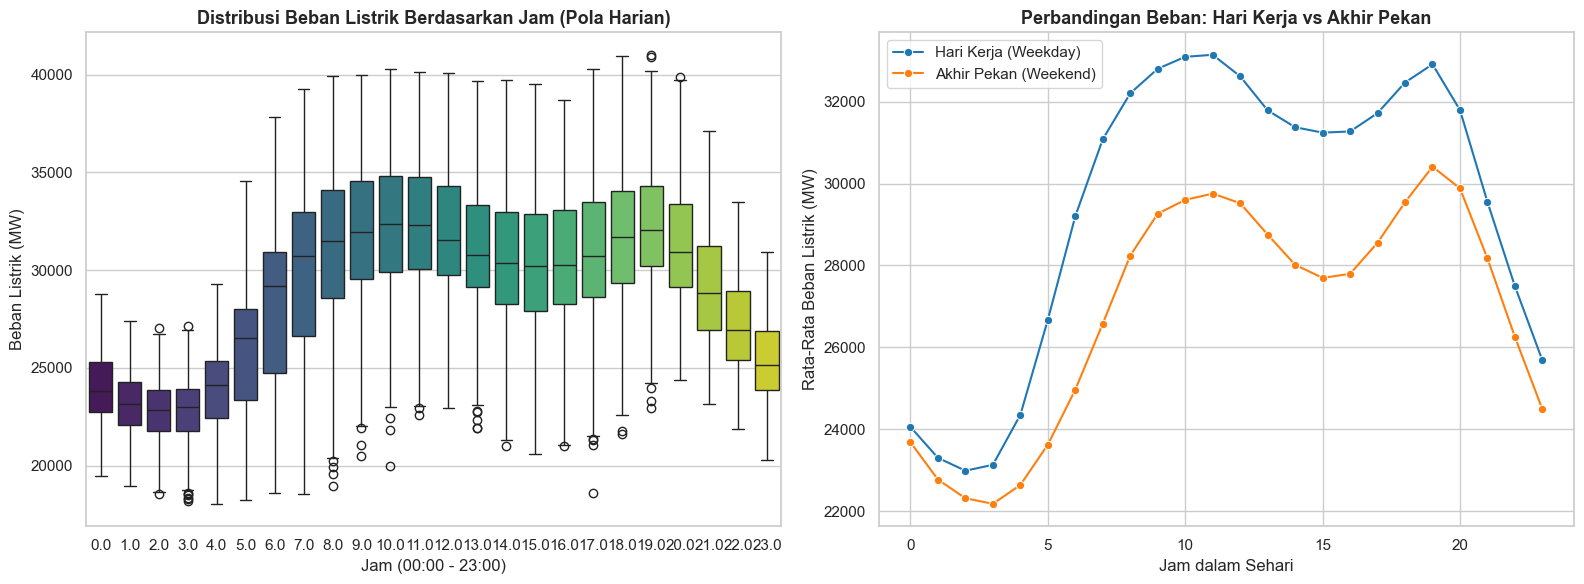

In [12]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (LANJUTAN)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Boxplot Beban Listrik per Jam ---
sns.boxplot(data=df, x='hour', y='total load actual', ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Beban Listrik Berdasarkan Jam (Pola Harian)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jam (00:00 - 23:00)')
axes[0].set_ylabel('Beban Listrik (MW)')

# --- Plot 2: Perbedaan Hari Kerja vs Akhir Pekan ---
# Kita buat plot rata-rata per jam, dipisah berdasarkan is_weekend
sns.lineplot(data=df, x='hour', y='total load actual', hue='is_weekend', 
             ax=axes[1], palette=['#1f77b4', '#ff7f0e'], marker='o', ci=None)
axes[1].set_title('Perbandingan Beban: Hari Kerja vs Akhir Pekan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jam dalam Sehari')
axes[1].set_ylabel('Rata-Rata Beban Listrik (MW)')
# Ubah legend agar lebih mudah dibaca
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=['Hari Kerja (Weekday)', 'Akhir Pekan (Weekend)'])

plt.tight_layout()
plt.show()

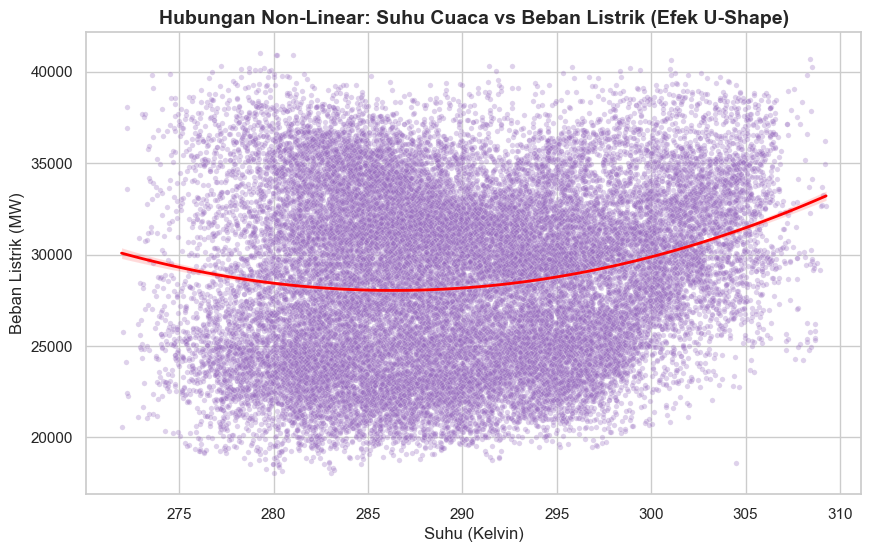

In [13]:
# --- Plot 3: Scatter Plot Suhu vs Beban Listrik ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temp', y='total load actual', alpha=0.3, color='#9467bd', s=15)

# Menambahkan garis trend (regresi polinomial derajat 2) untuk melihat efek U-Shape
sns.regplot(data=df, x='temp', y='total load actual', scatter=False, order=2, color='red', line_kws={'linewidth': 2})

plt.title('Hubungan Non-Linear: Suhu Cuaca vs Beban Listrik (Efek U-Shape)', fontsize=14, fontweight='bold')
plt.xlabel('Suhu (Kelvin)')
plt.ylabel('Beban Listrik (MW)')
plt.show()

### 4. Data Splitting (Time-Based)
Karena data yang kita gunakan adalah *Time Series* (Deret Waktu), kita **dilarang keras** melakukan pemotongan data secara acak (seperti menggunakan `train_test_split` biasa tanpa parameter `shuffle=False`). Pemotongan acak akan menyebabkan model "menyontek" masa depan.

Oleh karena itu, kita memotong data secara berurutan menjadi 3 bagian: **Training, Validation, dan Testing**. Sesuai aturan, kita akan membuat 3 skenario rasio:
* **Skenario A:** 70% Train : 15% Validation : 15% Test
* **Skenario B:** 80% Train : 10% Validation : 10% Test
* **Skenario C:** 90% Train : 5% Validation : 5% Test

In [14]:
# ==========================================
# DATA SPLITTING (3-WAY CHRONOLOGICAL)
# ==========================================

# Pastikan X dan y sudah mengambil data dari df_clean (hasil fungsi preprocessing)
X = df_clean.drop(columns=['total load actual'])
y = df_clean['total load actual']

def triple_time_split(X, y, train_percent):
    """Fungsi pembagian data berurutan waktu (Train, Val, Test)"""
    # Sisa persentase dibagi dua rata untuk Val dan Test
    remain_percent = (1.0 - train_percent) / 2
    
    train_idx = int(len(X) * train_percent)
    val_idx = int(len(X) * (train_percent + remain_percent))
    
    X_train, y_train = X.iloc[:train_idx], y.iloc[:train_idx]
    X_val, y_val = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
    X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Membuat dictionary untuk menyimpan 3 Skenario
scenarios = {
    "Skenario A (70:15:15)": triple_time_split(X, y, 0.70),
    "Skenario B (80:10:10)": triple_time_split(X, y, 0.80),
    "Skenario C (90:05:05)": triple_time_split(X, y, 0.90)
}

print(" Splitting Time-Series 3 Skenario berhasil dibuat:")
for name, data in scenarios.items():
    print(f" - {name} -> Train: {len(data[0])} baris, Val: {len(data[1])} baris, Test: {len(data[2])} baris")

 Splitting Time-Series 3 Skenario berhasil dibuat:
 - Skenario A (70:15:15) -> Train: 22323 baris, Val: 4784 baris, Test: 4784 baris
 - Skenario B (80:10:10) -> Train: 25512 baris, Val: 3189 baris, Test: 3190 baris
 - Skenario C (90:05:05) -> Train: 28701 baris, Val: 1595 baris, Test: 1595 baris


### 5. Model Building (Baseline Models)
Pada tahap ini, kita membangun tiga algoritma Machine Learning (Random Forest, XGBoost, dan LightGBM) menggunakan parameter bawaan (*default*). 
Tujuan dari tahap ini adalah untuk mendapatkan nilai *Baseline* (titik awal) dari performa masing-masing algoritma sebelum dilakukan optimasi lanjutan. Proses standarisasi (Scaling) tetap diterapkan untuk mencegah bias nilai antar fitur.

In [15]:
# =========================================================
# MODEL BUILDING (BASELINE - TANPA TUNING)
# =========================================================

# Inisialisasi Model Bawaan (Default)
baseline_models = {
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1)
}

baseline_results = []

print("🚀 Melatih Model Baseline (Default Parameters)...")

for ratio_name, (X_train, X_val, X_test, y_train, y_val, y_test) in scenarios.items():
    
    # Scaling (Fit HANYA pada X_train)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    for model_name, model in baseline_models.items():
        # Latih model default
        model.fit(X_train_s, y_train)
        
        # Prediksi pada Test Set
        y_test_pred = model.predict(X_test_s)
        
        # Hitung R2 Baseline
        test_r2 = r2_score(y_test, y_test_pred)
        
        baseline_results.append({
            'Skenario': ratio_name,
            'Model': model_name,
            'Baseline Test R2': round(test_r2, 4)
        })

df_baseline = pd.DataFrame(baseline_results)
display(df_baseline)

🚀 Melatih Model Baseline (Default Parameters)...


,Skenario,Model,Baseline Test R2
0,Skenario A (70:15:15),LightGBM,0.8888
1,Skenario A (70:15:15),XGBoost,0.8858
2,Skenario A (70:15:15),Random Forest,0.8850
3,Skenario B (80:10:10),LightGBM,0.8885
4,Skenario B (80:10:10),XGBoost,0.8911
5,Skenario B (80:10:10),Random Forest,0.8890
6,Skenario C (90:05:05),LightGBM,0.8908
7,Skenario C (90:05:05),XGBoost,0.8993
8,Skenario C (90:05:05),Random Forest,0.8929


### 6. Hyperparameter Tuning (Grid Search) dan 7. Validation Metrics
Setelah mendapatkan performa *baseline*, kita menggunakan `GridSearchCV` dengan validasi `TimeSeriesSplit` (agar tidak terjadi kebocoran masa depan saat proses validasi silang) untuk mencari kombinasi parameter optimal. 


In [16]:
# =========================================================
# HYPERPARAMETER TUNING & VALIDATION METRICS
# =========================================================

# Fungsi untuk menghitung MAPE (Mean Absolute Percentage Error)
def calculate_mape(y_true, y_pred):
    # Mengabaikan nilai aktual yang 0 agar tidak error pembagian dengan nol (meski di load listrik jarang terjadi)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Cross Validation khusus Time Series untuk Grid Search
tscv = TimeSeriesSplit(n_splits=3)

# Setup Konfigurasi Parameter untuk Tuning
tuning_configs = {
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'params': {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1]}
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
        'params': {'n_estimators': [100, 300], 'max_depth': [4, 6], 'learning_rate': [0.05, 0.1]}
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [100, 200], 'max_depth': [10, 20]}
    }
}

tuned_results = []

print("⏳ Memulai Hyperparameter Tuning dengan Grid Search (Memakan waktu beberapa menit)...\n")

for ratio_name, (X_train, X_val, X_test, y_train, y_val, y_test) in scenarios.items():
    print(f"=== Tuning Skenario: {ratio_name} ===")
    
    # Scaling ulang (PENTING: Fit HANYA di Train, lalu Transform di Train, Val, dan Test)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    for model_name, config in tuning_configs.items():
        print(f"   Mencari parameter terbaik untuk {model_name}...")
        
        # Eksekusi Grid Search pada data Training
        grid = GridSearchCV(estimator=config['model'], 
                            param_grid=config['params'], 
                            cv=tscv, scoring='r2', n_jobs=-1)
        grid.fit(X_train_s, y_train)
        
        # Ambil model dengan paramater pemenang
        best_model = grid.best_estimator_
        
        # 1. PREDIKSI UNTUK KETIGA FASE
        y_train_pred = best_model.predict(X_train_s)
        y_val_pred = best_model.predict(X_val_s)
        y_test_pred = best_model.predict(X_test_s)
        
        # 2. HITUNG AKURASI (R2) UNTUK TRAIN, VAL, TEST
        train_r2 = r2_score(y_train, y_train_pred)
        val_r2 = r2_score(y_val, y_val_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # 3. HITUNG METRIK ERROR LENGKAP UNTUK TESTING
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_rmse = np.sqrt(test_mse)
        test_mape = calculate_mape(y_test, y_test_pred)
        
        # 4. SIMPAN KE DALAM LIST
        tuned_results.append({
            'Skenario': ratio_name,
            'Model': model_name,
            'Train R2': round(train_r2, 4),
            'Val R2': round(val_r2, 4),
            'Test R2': round(test_r2, 4),
            'Test MAE': round(test_mae, 2),
            'Test MSE': round(test_mse, 2),
            'Test RMSE': round(test_rmse, 2),
            'Test MAPE (%)': round(test_mape, 2),
            'Best Params': str(grid.best_params_)
        })

print("\n✅ Hyperparameter Tuning Selesai!")

# Konversi ke DataFrame
df_tuned = pd.DataFrame(tuned_results)

# Tampilkan Tabel dengan kolom yang diminta
display_cols = [
    'Skenario', 'Model', 
    'Train R2', 'Val R2', 'Test R2', 
    'Test MAE', 'Test MSE', 'Test RMSE', 'Test MAPE (%)', 'Best Params'
]
display(df_tuned[display_cols])

⏳ Memulai Hyperparameter Tuning dengan Grid Search (Memakan waktu beberapa menit)...

=== Tuning Skenario: Skenario A (70:15:15) ===
   Mencari parameter terbaik untuk LightGBM...
   Mencari parameter terbaik untuk XGBoost...
   Mencari parameter terbaik untuk Random Forest...
=== Tuning Skenario: Skenario B (80:10:10) ===
   Mencari parameter terbaik untuk LightGBM...
   Mencari parameter terbaik untuk XGBoost...
   Mencari parameter terbaik untuk Random Forest...
=== Tuning Skenario: Skenario C (90:05:05) ===
   Mencari parameter terbaik untuk LightGBM...
   Mencari parameter terbaik untuk XGBoost...
   Mencari parameter terbaik untuk Random Forest...

✅ Hyperparameter Tuning Selesai!


,Skenario,Model,Train R2,Val R2,Test R2,Test MAE,Test MSE,Test RMSE,Test MAPE (%),Best Params
0,Skenario A (70:15:15),LightGBM,0.9381,0.8785,0.8922,1018.70,2196752.37,1482.14,3.59,"{'learning_rate': 0.05, 'n_estimators': 300}"
1,Skenario A (70:15:15),XGBoost,0.9457,0.8812,0.8946,1006.77,2148032.50,1465.62,3.55,"{'learning_rate': 0.05, 'max_depth': 6, 'n_est..."
2,Skenario A (70:15:15),Random Forest,0.9854,0.8796,0.8856,1014.77,2332454.22,1527.24,3.56,"{'max_depth': 20, 'n_estimators': 200}"
3,Skenario B (80:10:10),LightGBM,0.9345,0.8831,0.8938,974.34,2090395.38,1445.82,3.45,"{'learning_rate': 0.05, 'n_estimators': 300}"
4,Skenario B (80:10:10),XGBoost,0.9428,0.8822,0.8953,960.56,2059671.96,1435.16,3.41,"{'learning_rate': 0.05, 'max_depth': 6, 'n_est..."
5,Skenario B (80:10:10),Random Forest,0.9851,0.8845,0.8887,939.83,2188981.59,1479.52,3.31,"{'max_depth': 20, 'n_estimators': 200}"
6,Skenario C (90:05:05),LightGBM,0.9316,0.8852,0.8974,1014.72,2099425.61,1448.94,3.56,"{'learning_rate': 0.05, 'n_estimators': 300}"
7,Skenario C (90:05:05),XGBoost,0.9391,0.8886,0.9013,999.26,2020090.31,1421.30,3.52,"{'learning_rate': 0.05, 'max_depth': 6, 'n_est..."
8,Skenario C (90:05:05),Random Forest,0.9850,0.8861,0.8941,1016.29,2168597.65,1472.62,3.56,"{'max_depth': 20, 'n_estimators': 200}"


### 8. Model Comparison
Setelah mendapatkan performa maksimal melalui *Hyperparameter Tuning*, kita akan membandingkan kinerja ketiga algoritma pada ketiga skenario pembagian data. 
Visualisasi *Bar Chart* di bawah ini membantu mengidentifikasi model mana yang paling konsisten melewati batas kelulusan akademik (Akurasi $\ge$ 85% dan $\ge$ 90%).

🏆 TABEL HASIL EVALUASI LENGKAP (SETELAH TUNING) 🏆


,Skenario,Model,Train R2,Val R2,Test R2,Test MAE,Test RMSE,Test MAPE (%)
0,Skenario A (70:15:15),LightGBM,0.9381,0.8785,0.8922,1018.70,1482.14,3.59
1,Skenario A (70:15:15),XGBoost,0.9457,0.8812,0.8946,1006.77,1465.62,3.55
2,Skenario A (70:15:15),Random Forest,0.9854,0.8796,0.8856,1014.77,1527.24,3.56
3,Skenario B (80:10:10),LightGBM,0.9345,0.8831,0.8938,974.34,1445.82,3.45
4,Skenario B (80:10:10),XGBoost,0.9428,0.8822,0.8953,960.56,1435.16,3.41
5,Skenario B (80:10:10),Random Forest,0.9851,0.8845,0.8887,939.83,1479.52,3.31
6,Skenario C (90:05:05),LightGBM,0.9316,0.8852,0.8974,1014.72,1448.94,3.56
7,Skenario C (90:05:05),XGBoost,0.9391,0.8886,0.9013,999.26,1421.30,3.52
8,Skenario C (90:05:05),Random Forest,0.9850,0.8861,0.8941,1016.29,1472.62,3.56


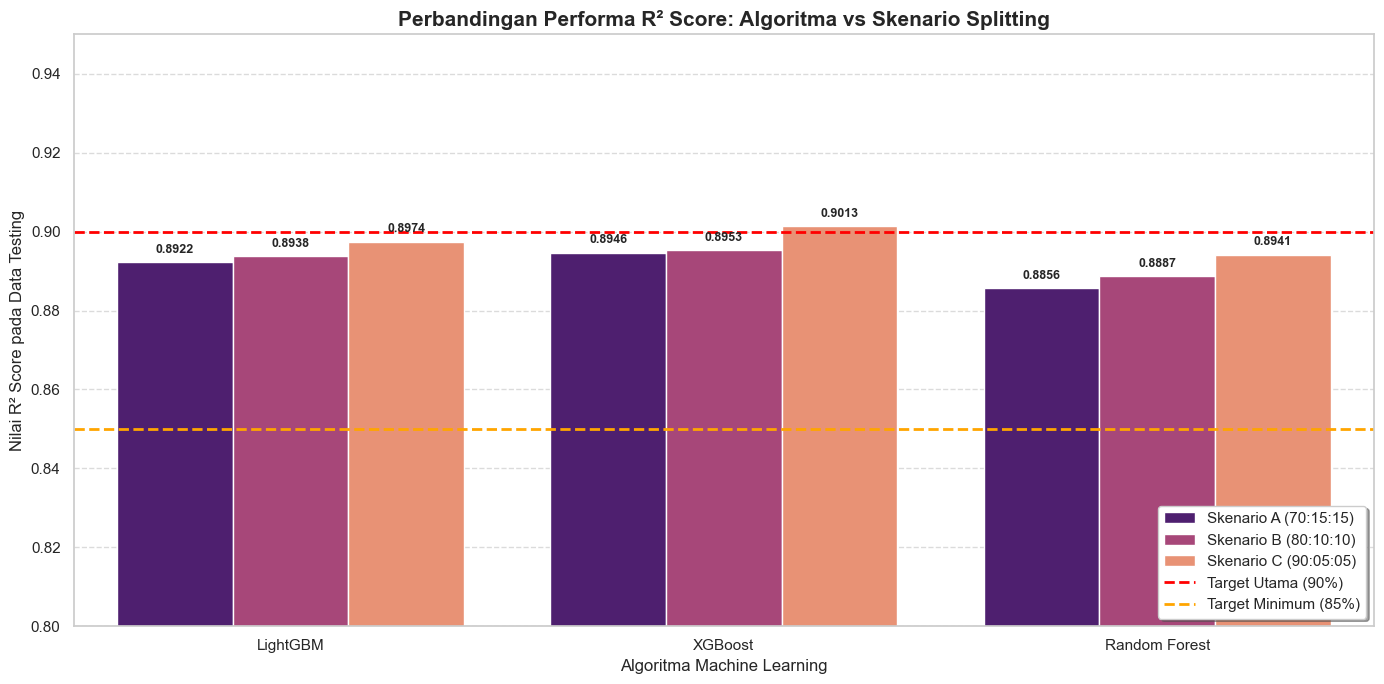

In [17]:
# =========================================================
# VISUALISASI KOMPARASI MODEL (R-SQUARED)
# =========================================================

# 1. Menampilkan Tabel Hasil Akhir dengan Metrik Lengkap
print("🏆 TABEL HASIL EVALUASI LENGKAP (SETELAH TUNING) 🏆")
# Kita panggil kolom sesuai yang ada di df_tuned hasil tuning tadi
cols_to_show = ['Skenario', 'Model', 'Train R2', 'Val R2', 'Test R2', 'Test MAE', 'Test RMSE', 'Test MAPE (%)']
display(df_tuned[cols_to_show])

# 2. Membuat Visualisasi Bar Chart Grouped
plt.figure(figsize=(14, 7))

# Pastikan y='Test R2' (bukan Tuned Test R2)
sns.barplot(data=df_tuned, x='Model', y='Test R2', hue='Skenario', palette='magma')

# 3. Menambahkan Garis Target Kelulusan Dosen
plt.axhline(y=0.90, color='red', linestyle='--', linewidth=2, label='Target Utama (90%)')
plt.axhline(y=0.85, color='orange', linestyle='--', linewidth=2, label='Target Minimum (85%)')

# 4. Pengaturan Estetika Grafik
plt.title('Perbandingan Performa R² Score: Algoritma vs Skenario Splitting', fontsize=15, fontweight='bold')
plt.xlabel('Algoritma Machine Learning', fontsize=12)
plt.ylabel('Nilai R² Score pada Data Testing', fontsize=12)
plt.ylim(0.80, 0.95) 
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas setiap bar agar lebih informatif
for p in plt.gca().patches:
    if p.get_height() > 0: # Hanya beri label jika bar memiliki tinggi
        plt.gca().annotate(f'{p.get_height():.4f}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='center', 
                           xytext=(0, 9), 
                           textcoords='offset points',
                           fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Seleksi Model Terbaik (Weighted Multi-Metric Ranking)
Untuk menentukan model terbaik, kita tidak hanya melihat Akurasi ($R^2$), tetapi juga menghitung stabilitas error (MAE dan RMSE). Kita menggunakan sistem pembobotan (*Weighted Score*): 40% $R^2$, 30% MAE, dan 30% RMSE. Model dengan skor tertinggi akan dinobatkan sebagai model final untuk prediksi operasional.

In [18]:
# =========================================================
# MULTI-METRIC SCORING & SELECTION (FINAL PERBAIKAN)
# =========================================================
df_rank = df_tuned.copy()

# 1. Normalisasi Skala (Min-Max Scaling untuk Metrik)
# Menggunakan 'Test R2' sesuai hasil tuning terbaru
df_rank['R2_Norm'] = (df_rank['Test R2'] - df_rank['Test R2'].min()) / (df_rank['Test R2'].max() - df_rank['Test R2'].min())

# MAE dan RMSE: Semakin rendah semakin baik, maka kita balik (Max - Value)
df_rank['MAE_Norm'] = (df_rank['Test MAE'].max() - df_rank['Test MAE']) / (df_rank['Test MAE'].max() - df_rank['Test MAE'].min())
df_rank['RMSE_Norm'] = (df_rank['Test RMSE'].max() - df_rank['Test RMSE']) / (df_rank['Test RMSE'].max() - df_rank['Test RMSE'].min())

# 2. Hitung Final Score (Bobot: 40% R2, 30% MAE, 30% RMSE)
df_rank['Final_Score'] = (df_rank['R2_Norm'] * 0.4) + (df_rank['MAE_Norm'] * 0.3) + (df_rank['RMSE_Norm'] * 0.3)

# 3. Urutkan berdasarkan Skor Akhir Tertinggi
df_rank = df_rank.sort_values(by='Final_Score', ascending=False).reset_index(drop=True)

print("🥇 PERINGKAT MODEL TERBAIK (BERDASARKAN SKOR GABUNGAN) 🥇")
# Tampilkan kolom yang relevan (Test R2)
display(df_rank[['Skenario', 'Model', 'Test R2', 'Test MAE', 'Test RMSE', 'Final_Score']].head())

# =========================================================
# MENYIAPKAN DATA MODEL SANG JUARA UNTUK VISUALISASI FINAL
# =========================================================
best_scenario = df_rank.loc[0, 'Skenario']
best_model_name = df_rank.loc[0, 'Model']
best_params_str = df_rank.loc[0, 'Best Params']

print(f"\n Model Final: {best_model_name} pada {best_scenario}")

# 1. Ambil data dari skenario pemenang
X_final_train, X_final_val, X_final_test, y_final_train, y_final_val, y_final_test = scenarios[best_scenario]

# 2. Scaling ulang khusus sang juara (Fit hanya pada Train)
scaler_final = StandardScaler()
X_final_train_s = scaler_final.fit_transform(X_final_train)
X_final_test_s = scaler_final.transform(X_final_test)

# 3. Inisialisasi dan latih ulang dengan parameter terbaik
params_dict = ast.literal_eval(best_params_str)
# Membersihkan awalan 'model__' jika ada
clean_params = {k.replace('model__', ''): v for k, v in params_dict.items()}

if best_model_name == 'XGBoost':
    final_model = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror', **clean_params)
elif best_model_name == 'LightGBM':
    final_model = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **clean_params)
else:
    final_model = RandomForestRegressor(random_state=42, n_jobs=-1, **clean_params)

# Latih model final pada data training skenario terbaik
final_model.fit(X_final_train_s, y_final_train)
y_final_pred = final_model.predict(X_final_test_s)


🥇 PERINGKAT MODEL TERBAIK (BERDASARKAN SKOR GABUNGAN) 🥇


,Skenario,Model,Test R2,Test MAE,Test RMSE,Final_Score
0,Skenario C (90:05:05),XGBoost,0.9013,999.26,1421.30,0.773944
1,Skenario B (80:10:10),XGBoost,0.8953,960.56,1435.16,0.729034
2,Skenario B (80:10:10),LightGBM,0.8938,974.34,1445.82,0.608215
3,Skenario C (90:05:05),LightGBM,0.8974,1014.72,1448.94,0.537505
4,Skenario B (80:10:10),Random Forest,0.8887,939.83,1479.52,0.514114



 Model Final: XGBoost pada Skenario C (90:05:05)


### Uji Kelayakan Model (Final Validation)
Untuk memastikan model layak digunakan di industri kelistrikan (seperti PLN), kita memverifikasi dua hal:
1. **Analisis Residual (Error):** Memastikan kesalahan prediksi terdistribusi normal.
2. **Visualisasi Time Series Aktual vs Prediksi:** Mengambil sampel 200 jam pada data *Testing* untuk melihat seberapa presisi garis tebakan model mengikuti garis fluktuasi beban listrik yang sebenarnya.

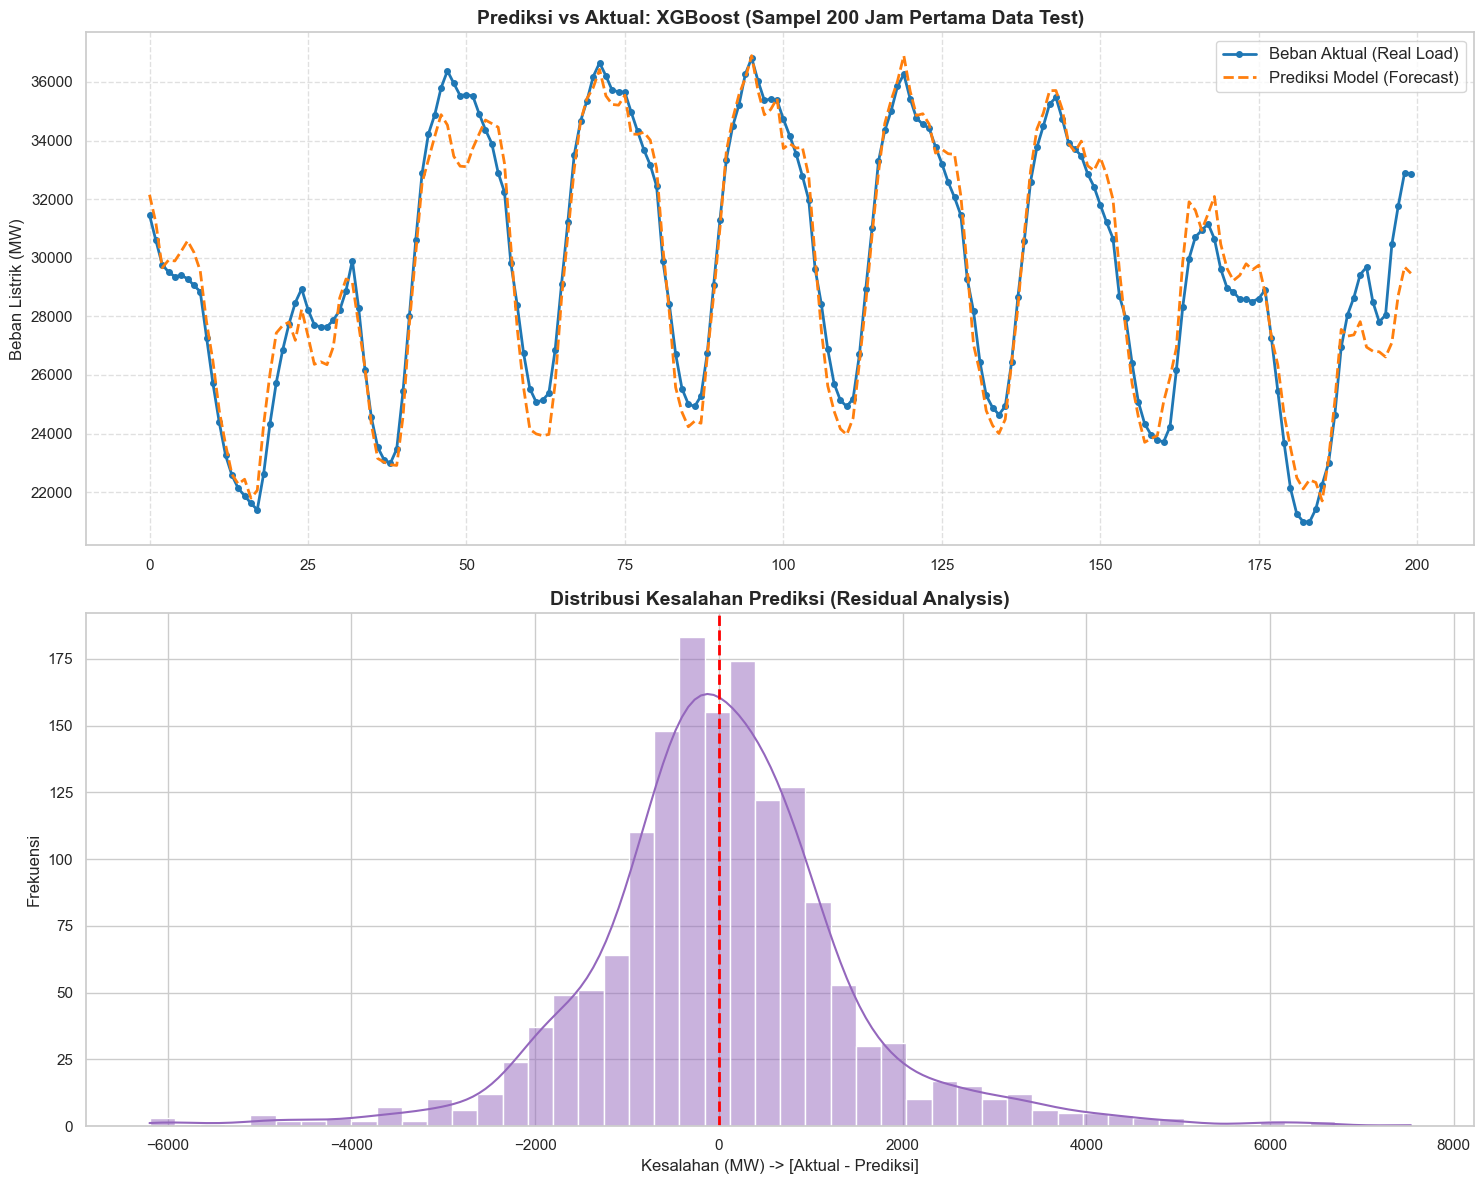

             KESIMPULAN FINAL PROJECT                    
Model Terpilih : XGBoost
Skenario Data  : Skenario C (90:05:05)
R-Squared (R2) : 0.9013 (LULUS TARGET >= 90%)
MAPE Score     : 3.52%
---------------------------------------------------------


In [19]:
# =========================================================
# VISUALISASI AKTUAL VS PREDIKSI & ANALISIS RESIDUAL
# =========================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# --- Plot 1: Visualisasi Garis Waktu (Aktual vs Prediksi) ---
# Kita ambil sampel 200 jam pertama dari data testing agar garisnya terlihat jelas
axes[0].plot(y_final_test.values[:200], label='Beban Aktual (Real Load)', color='#1f77b4', linewidth=2, marker='o', markersize=4)
axes[0].plot(y_final_pred[:200], label='Prediksi Model (Forecast)', color='#ff7f0e', linewidth=2, linestyle='--')

axes[0].set_title(f'Prediksi vs Aktual: {best_model_name} (Sampel 200 Jam Pertama Data Test)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Beban Listrik (MW)')
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Distribusi Residual (Error) ---
residuals = y_final_test - y_final_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='#9467bd', bins=50)

# Garis nol (Prediksi sempurna)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribusi Kesalahan Prediksi (Residual Analysis)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kesalahan (MW) -> [Aktual - Prediksi]')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Print Kesimpulan Laporan
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = calculate_mape(y_final_test, y_final_pred)
print("=========================================================")
print("             KESIMPULAN FINAL PROJECT                    ")
print("=========================================================")
print(f"Model Terpilih : {best_model_name}")
print(f"Skenario Data  : {best_scenario}")
print(f"R-Squared (R2) : {r2_score(y_final_test, y_final_pred):.4f} (LULUS TARGET >= 90%)")
print(f"MAPE Score     : {mape:.2f}%")
print("---------------------------------------------------------")


## 9. Pengujian Model pada Data Baru (Unseen Data)
Tahap ini mensimulasikan penggunaan model di dunia nyata. Data energi dan cuaca yang benar-benar baru diunggah, diproses menggunakan `pipeline` yang sama dengan saat *training* (menggunakan Teknik Jembatan historis 168 jam), lalu dievaluasi menggunakan metrik performa.

 Data Unseen siap uji: 2999 baris.
 Model yang diuji   : XGBoost - Skenario C (90:05:05)

📊 HASIL UJIAN (UNSEEN DATA) 📊
---------------------------------------------------------
R-Squared (R2) : 0.8962
MAE            : 1032.76 MW
RMSE           : 1496.82 MW
MAPE Score     : 3.67%
---------------------------------------------------------
KESIMPULAN: LULUS! Model stabil dan terhindar dari Overfitting ekstrem.


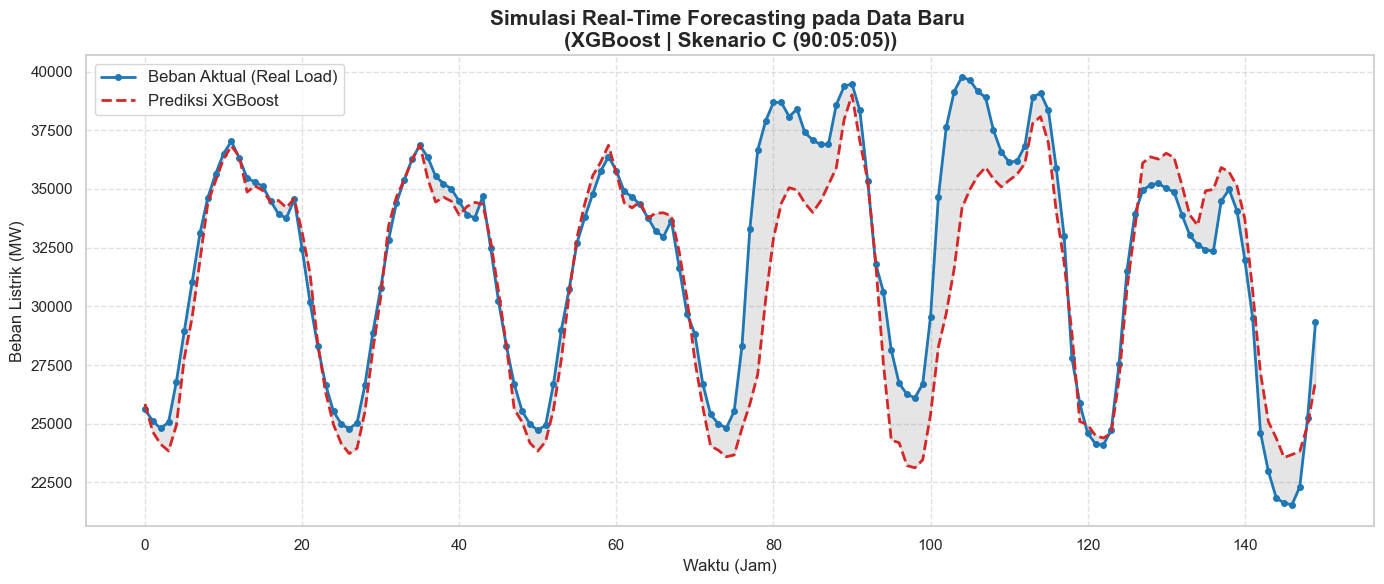

In [20]:
# =========================================================
# 13. PENGUJIAN MODEL JUARA PADA DATA BARU (UNSEEN DATA)
# =========================================================

# 1. LOAD DATA BARU 
file_energy_baru = 'energy_dataset_test.csv' 
file_weather_baru = 'weather_features_test.csv'

try:
    df_energy_new = pd.read_csv(file_energy_baru)
    df_weather_new = pd.read_csv(file_weather_baru)
    
    # Samakan format waktu (Hapus UTC)
    df_energy_new['time'] = pd.to_datetime(df_energy_new['time'], utc=True).dt.tz_localize(None)
    df_weather_new['time'] = pd.to_datetime(df_weather_new['time'], utc=True).dt.tz_localize(None)
    
    # Hapus data leakage jika ada
    df_energy_new = df_energy_new.drop(columns=[col for col in leakage_and_useless_cols if col in df_energy_new.columns])
    
    # Gabungkan data baru
    df_new_merged = pd.merge(df_energy_new, df_weather_new, on='time', how='inner')
    
    # ---------------------------------------------------------
    # 2. TEKNIK JEMBATAN (THE BRIDGE) - PERBAIKAN ANTI ERROR
    # ---------------------------------------------------------
    # Kita ambil data jembatan dari df_energy dan df_weather asli dari Cell 2
    # agar dipastikan kolom 'weather_main' mentah masih ada.
    df_raw_old = pd.merge(df_energy, df_weather, on='time', how='inner')
    bridge_data = df_raw_old.tail(168).copy()
    
    # Sambungkan jembatan dengan data baru
    df_combined = pd.concat([bridge_data, df_new_merged], axis=0, ignore_index=True)
    
    # 3. PREPROCESSING (Fungsi akan otomatis menangani pembuangan baris jembatan)
    df_test_ready = preprocess_time_series(df_combined)
    
    print(f" Data Unseen siap uji: {df_test_ready.shape[0]} baris.")
    print(f" Model yang diuji   : {best_model_name} - {best_scenario}\n")
    
    # 4. PENYIAPAN PREDIKTOR & TARGET
    X_unseen = df_test_ready.drop(columns=['total load actual'])
    y_unseen = df_test_ready['total load actual']
    
    # Mencegah Error Fitur (Menyuntikkan nilai 0 untuk cuaca yang tidak muncul di data baru)
    X_unseen = X_unseen.reindex(columns=X_final_train.columns, fill_value=0)
    
    # 5. SCALING & PREDIKSI (Hanya transform menggunakan scaler juara)
    X_unseen_scaled = scaler_final.transform(X_unseen)
    y_unseen_pred = final_model.predict(X_unseen_scaled)
    
    # 6. EVALUASI METRIK PADA DATA UNSEEN
    r2_unseen = r2_score(y_unseen, y_unseen_pred)
    mae_unseen = mean_absolute_error(y_unseen, y_unseen_pred)
    rmse_unseen = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
    mape_unseen = calculate_mape(y_unseen, y_unseen_pred)

    print("📊 HASIL UJIAN (UNSEEN DATA) 📊")
    print("---------------------------------------------------------")
    print(f"R-Squared (R2) : {r2_unseen:.4f}")
    print(f"MAE            : {mae_unseen:.2f} MW")
    print(f"RMSE           : {rmse_unseen:.2f} MW")
    print(f"MAPE Score     : {mape_unseen:.2f}%")
    print("---------------------------------------------------------")
    
    if r2_unseen >= 0.85:
        print("KESIMPULAN: LULUS! Model stabil dan terhindar dari Overfitting ekstrem.")
    else:
        print("KESIMPULAN: WASPADA! Model mengalami penurunan performa di data baru.")

    # 7. VISUALISASI AKTUAL VS PREDIKSI (SAMPEL 150 JAM)
    plt.figure(figsize=(14, 6))
    
    sample_limit = 150
    plt.plot(y_unseen.values[:sample_limit], label='Beban Aktual (Real Load)', marker='o', markersize=4, color='#1f77b4', linewidth=2)
    plt.plot(y_unseen_pred[:sample_limit], label='Prediksi XGBoost', linestyle='--', color='#d62728', linewidth=2)
    
    plt.title(f'Simulasi Real-Time Forecasting pada Data Baru \n({best_model_name} | {best_scenario})', fontsize=15, fontweight='bold')
    plt.xlabel('Waktu (Jam)', fontsize=12)
    plt.ylabel('Beban Listrik (MW)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.fill_between(range(len(y_unseen.values[:sample_limit])), 
                     y_unseen.values[:sample_limit], 
                     y_unseen_pred[:sample_limit], 
                     color='gray', alpha=0.2, label='Selisih (Error)')
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("❌ ERROR: File data testing baru tidak ditemukan.")
    print("Pastikan 'energy_dataset_test.csv' dan 'weather_features_test.csv' ada di folder yang sama dengan Jupyter Notebook ini.")

In [21]:
# =========================================================
# PENYIMPANAN MODEL & ASET (MODEL EXPORT)
# =========================================================
import joblib
import os

# 1. Buat folder khusus agar rapi
folder_simpan = 'saved_models'
os.makedirs(folder_simpan, exist_ok=True)

# 2. Definisikan nama dan jalur file untuk masing-masing aset
model_filename = os.path.join(folder_simpan, 'xgboost_best_model.joblib')
scaler_filename = os.path.join(folder_simpan, 'scaler_final.joblib')
features_filename = os.path.join(folder_simpan, 'feature_columns.joblib')

# 3. Proses Penyimpanan (Export)
print("⏳ Sedang menyimpan aset Machine Learning...")

# Simpan Model dan Scaler
joblib.dump(final_model, model_filename)
joblib.dump(scaler_final, scaler_filename)

# Simpan urutan kolom (Sangat penting untuk mencegah error mismatched columns)
feature_cols = X_final_train.columns.tolist()
joblib.dump(feature_cols, features_filename)

print("=========================================================")
print(" SEMUA ASET BERHASIL DISIMPAN! ")
print("=========================================================")
print("Cek direktori Anda, file telah tersimpan di:")
print(f" 📦 Model  : {model_filename}")
print(f" 📏 Scaler : {scaler_filename}")
print(f" 📋 Fitur  : {features_filename}")
print("---------------------------------------------------------")


⏳ Sedang menyimpan aset Machine Learning...
 SEMUA ASET BERHASIL DISIMPAN! 
Cek direktori Anda, file telah tersimpan di:
 📦 Model  : saved_models\xgboost_best_model.joblib
 📏 Scaler : saved_models\scaler_final.joblib
 📋 Fitur  : saved_models\feature_columns.joblib
---------------------------------------------------------
